# Chapter 15: Building End-to-End Precision Oncology Systems

## Hands-On Jupyter Notebook

This notebook simulates a precision-oncology decision stack combining biomarkers, pathway context, and care-action tiers.

**Time to Complete**: 1-2 hours

---

## Section 1: Setup and Imports

We configure a deterministic precision-oncology planning workflow.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

# Configuration
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print('Environment configured for Chapter 15 precision oncology notebook.')

Environment configured for Chapter 15 precision oncology notebook.


## Section 2: Load Data and Explore

We create a synthetic cohort with biomarker-pathway context for action-tier selection.

In [2]:
precision_df = pd.DataFrame([
    {'patient_id': 'prec_01', 'diagnosis': 'NSCLC', 'biomarker': 'EGFR', 'pathway': 'RTK-MAPK', 'therapy_class': 'TKI', 'risk_level': 'high'},
    {'patient_id': 'prec_02', 'diagnosis': 'CRC', 'biomarker': 'BRAF', 'pathway': 'MAPK', 'therapy_class': 'BRAF inhibitor', 'risk_level': 'medium'},
    {'patient_id': 'prec_03', 'diagnosis': 'Breast cancer', 'biomarker': 'ERBB2', 'pathway': 'HER2 signaling', 'therapy_class': 'antibody', 'risk_level': 'medium'},
    {'patient_id': 'prec_04', 'diagnosis': 'Glioma', 'biomarker': 'H3F3A', 'pathway': 'chromatin', 'therapy_class': 'investigational', 'risk_level': 'high'},
    {'patient_id': 'prec_05', 'diagnosis': 'NSCLC', 'biomarker': 'ALK', 'pathway': 'RTK', 'therapy_class': 'TKI', 'risk_level': 'medium'},
])
display(precision_df)

,patient_id,diagnosis,biomarker,pathway,therapy_class,risk_level
0,prec_01,NSCLC,EGFR,RTK-MAPK,TKI,high
1,prec_02,CRC,BRAF,MAPK,BRAF inhibitor,medium
2,prec_03,Breast cancer,ERBB2,HER2 signaling,antibody,medium
3,prec_04,Glioma,H3F3A,chromatin,investigational,high
4,prec_05,NSCLC,ALK,RTK,TKI,medium


## Section 3: Main Analysis

We convert risk and pathway context into composite priority and action tiers.

In [3]:
action_map = {'high': 'tumor_board', 'medium': 'specialist_review', 'low': 'routine_review'}
pathway_priority = {'RTK-MAPK': 3, 'MAPK': 2, 'HER2 signaling': 2, 'RTK': 2, 'chromatin': 1}

precision_df['action_tier'] = precision_df['risk_level'].map(action_map)
precision_df['pathway_score'] = precision_df['pathway'].map(pathway_priority)
precision_df['composite_priority'] = precision_df['pathway_score'] + precision_df['risk_level'].map({'low': 1, 'medium': 2, 'high': 3})
precision_summary = precision_df.groupby('action_tier', as_index=False).agg(cases=('patient_id', 'count'), avg_priority=('composite_priority', 'mean'))
precision_summary['avg_priority'] = precision_summary['avg_priority'].round(2)
display(precision_df)
display(precision_summary)

,patient_id,diagnosis,biomarker,pathway,therapy_class,risk_level,action_tier,pathway_score,composite_priority
0,prec_01,NSCLC,EGFR,RTK-MAPK,TKI,high,tumor_board,3,6
1,prec_02,CRC,BRAF,MAPK,BRAF inhibitor,medium,specialist_review,2,4
2,prec_03,Breast cancer,ERBB2,HER2 signaling,antibody,medium,specialist_review,2,4
3,prec_04,Glioma,H3F3A,chromatin,investigational,high,tumor_board,1,4
4,prec_05,NSCLC,ALK,RTK,TKI,medium,specialist_review,2,4


,action_tier,cases,avg_priority
0,specialist_review,3,4.0
1,tumor_board,2,5.0


## Section 4: Visualization

We inspect case volume by action tier and priority distribution across risk levels.

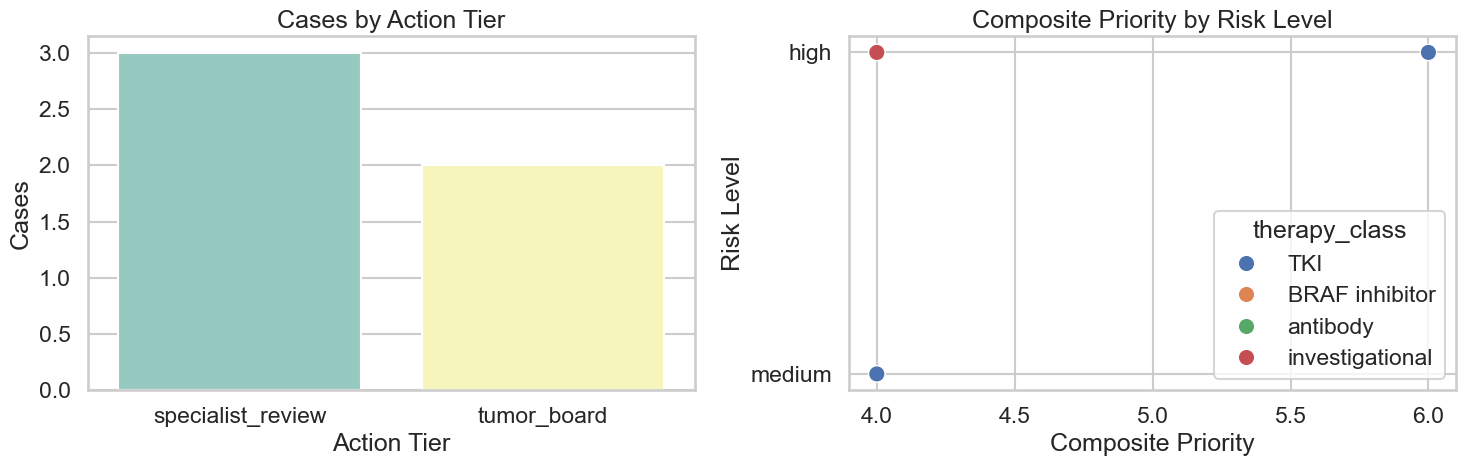

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=precision_summary, x='action_tier', y='cases', ax=axes[0], palette='Set3')
axes[0].set_title('Cases by Action Tier')
axes[0].set_xlabel('Action Tier')
axes[0].set_ylabel('Cases')

sns.scatterplot(data=precision_df, x='composite_priority', y='risk_level', hue='therapy_class', s=140, ax=axes[1])
axes[1].set_title('Composite Priority by Risk Level')
axes[1].set_xlabel('Composite Priority')
axes[1].set_ylabel('Risk Level')

plt.tight_layout()
plt.show()

## Section 5: Exercises

### Exercise 1: Action Tiering

*Description: List each patient with their assigned action tier for workflow routing.*

In [5]:
tier_df = precision_df[['patient_id', 'diagnosis', 'action_tier']].copy()
display(tier_df)

,patient_id,diagnosis,action_tier
0,prec_01,NSCLC,tumor_board
1,prec_02,CRC,specialist_review
2,prec_03,Breast cancer,specialist_review
3,prec_04,Glioma,tumor_board
4,prec_05,NSCLC,specialist_review


### Exercise 2: Recommendation Draft

*Description: Draft one sentence per patient summarizing the recommended next action.*

In [6]:
recommendation_df = precision_df[['patient_id', 'diagnosis', 'biomarker', 'action_tier']].copy()
recommendation_df['recommendation'] = recommendation_df.apply(lambda row: f"{row['diagnosis']} with {row['biomarker']} should go to {row['action_tier']}", axis=1)
display(recommendation_df[['patient_id', 'recommendation']])

,patient_id,recommendation
0,prec_01,NSCLC with EGFR should go to tumor_board
1,prec_02,CRC with BRAF should go to specialist_review
2,prec_03,Breast cancer with ERBB2 should go to speciali...
3,prec_04,Glioma with H3F3A should go to tumor_board
4,prec_05,NSCLC with ALK should go to specialist_review


## Section 6: Key Takeaways

- Precision oncology decisions combine biomarker and pathway context.
- Action tiers help route cases to appropriate review lanes.
- Compact recommendation text supports handoffs to care teams.

---

## Next Steps

1. ✅ Complete all exercises
2. 📖 Read Chapter 16 (next chapter)
3. 🔗 Review graph and trial chapters as needed
4. 🧪 Extend these tiering rules for your own cohorts

---

**Last Updated**: May 2026